Import Libraries

In [159]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

Load the Dataset

In [160]:
import importlib
import dataset_analysis  
importlib.reload(dataset_analysis)

X, y = dataset_analysis.load_dataset()
print("Dataset loaded")
print("X shape:", X.shape)
print("Y shape:", y.shape)

Total images found: 614


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Dataset loaded
X shape: (614, 6)
Y shape: (614,)


Split the Training and Test Data (80/20)

In [161]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 491
Testing Samples: 123


Create, Train and Test SVM Model

In [173]:
model = SVC(kernel="linear")
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Evaluate the Model on Accuracy, Precision and Recall

In [174]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 0.7235772357723578
Precision: 0.6530612244897959
Recall: 1.0


Confusion Matrix

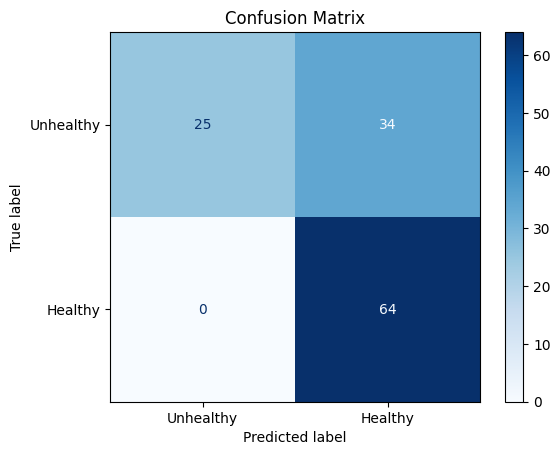

In [175]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Unhealthy", "Healthy"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()